In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [45]:
import pandas as pd

# The dataset 'indian_liver_patient.csv' is now available in /content/sample_data.
# We will load it directly from there.
patients = pd.read_csv('/content/sample_data/indian_liver_patient.csv')

In [46]:
patients.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [47]:
patients.shape

(583, 11)

In [48]:
patients['Gender']=patients['Gender'].apply(lambda x:1 if x=='Male' else 0)

In [49]:
patients.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


<Axes: xlabel='Gender'>

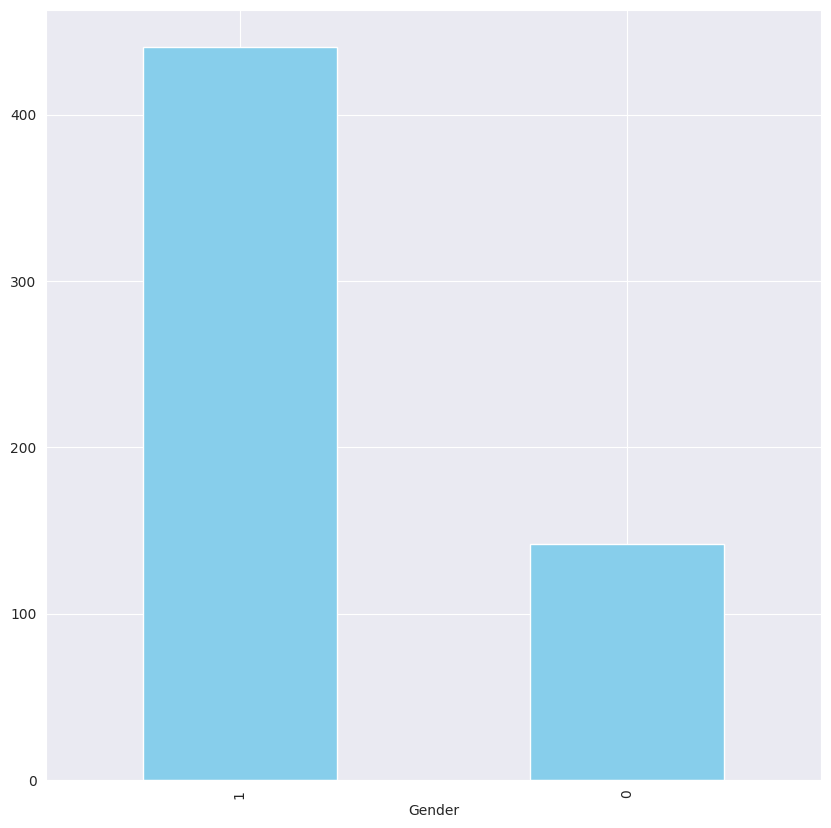

In [50]:
patients['Gender'].value_counts().plot.bar(color='skyblue')

<Axes: xlabel='Dataset'>

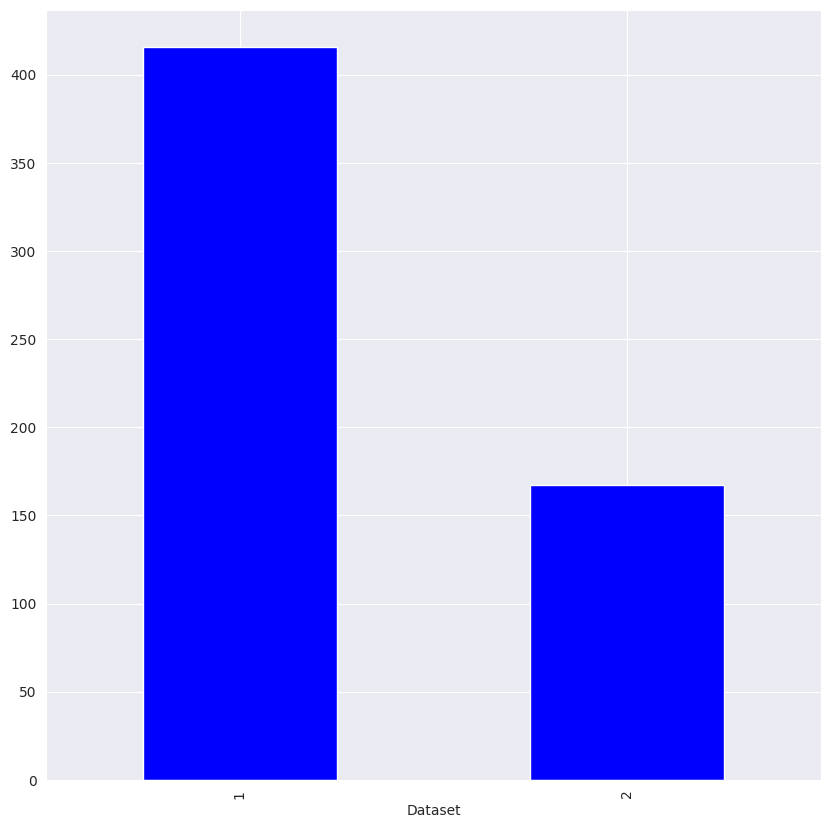

In [51]:
patients['Dataset'].value_counts().plot.bar(color='blue')

In [52]:
patients.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [53]:
patients['Albumin_and_Globulin_Ratio'].mean()

np.float64(0.9470639032815197)

In [54]:
patients=patients.fillna(0.94)

In [55]:
patients.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,0


<Axes: xlabel='Age'>

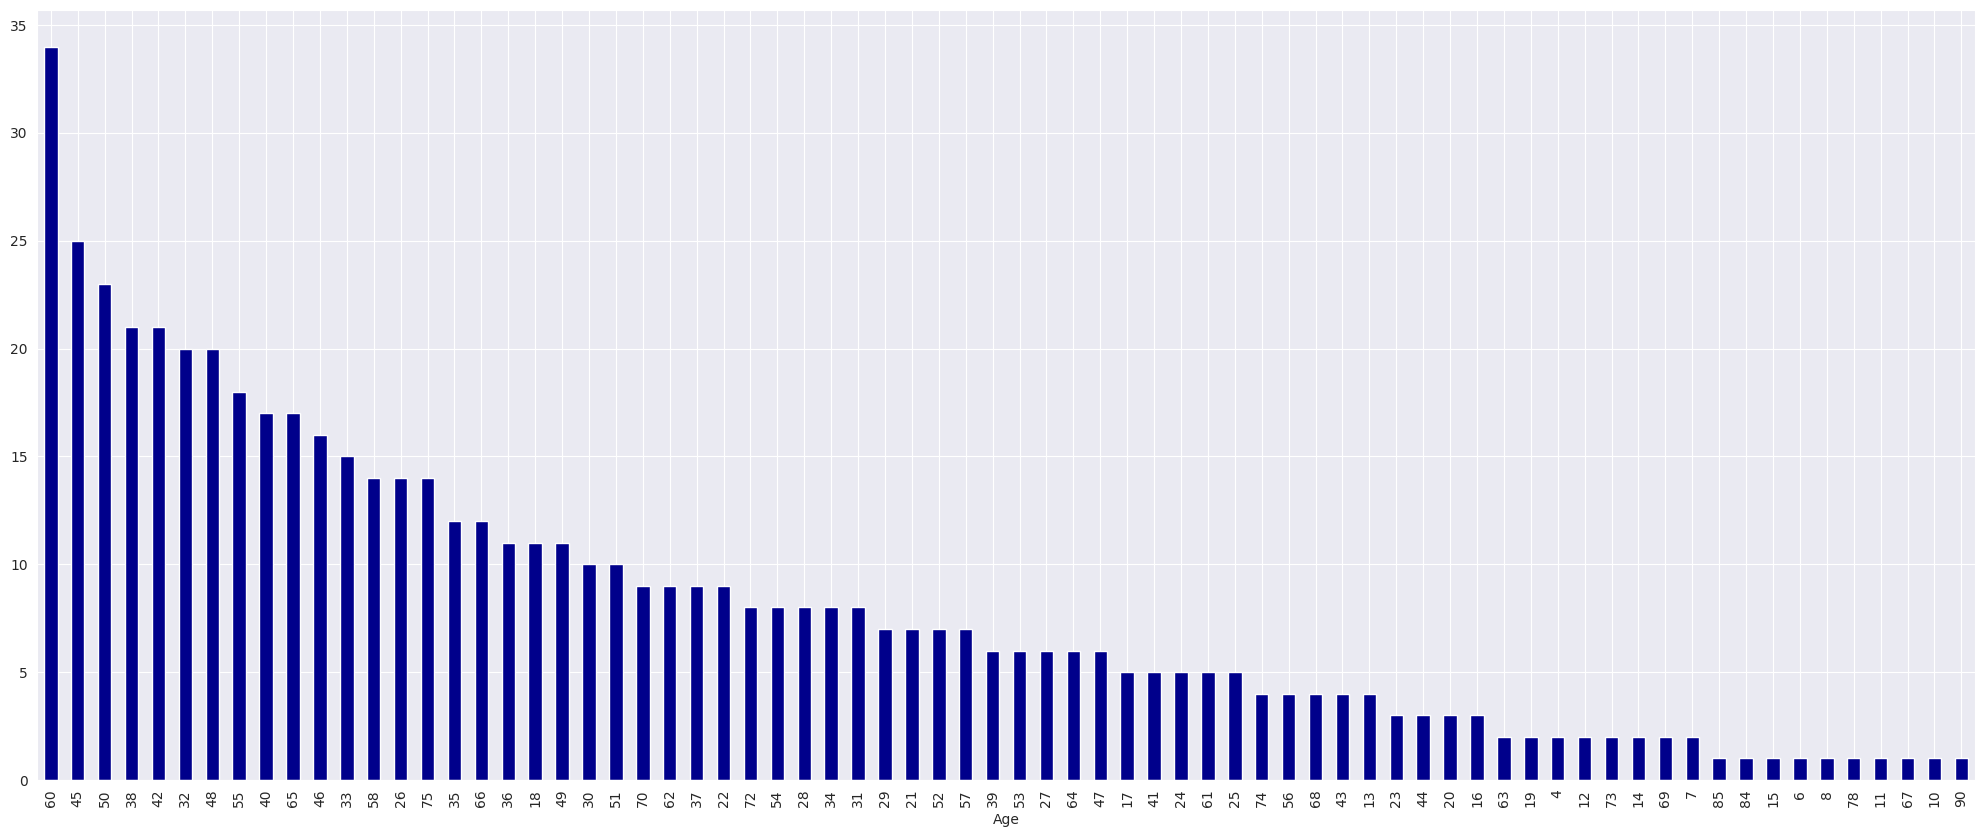

In [56]:
sns.set_style('darkgrid')
plt.figure(figsize=(25,10))
patients['Age'].value_counts().plot.bar(color='darkblue')

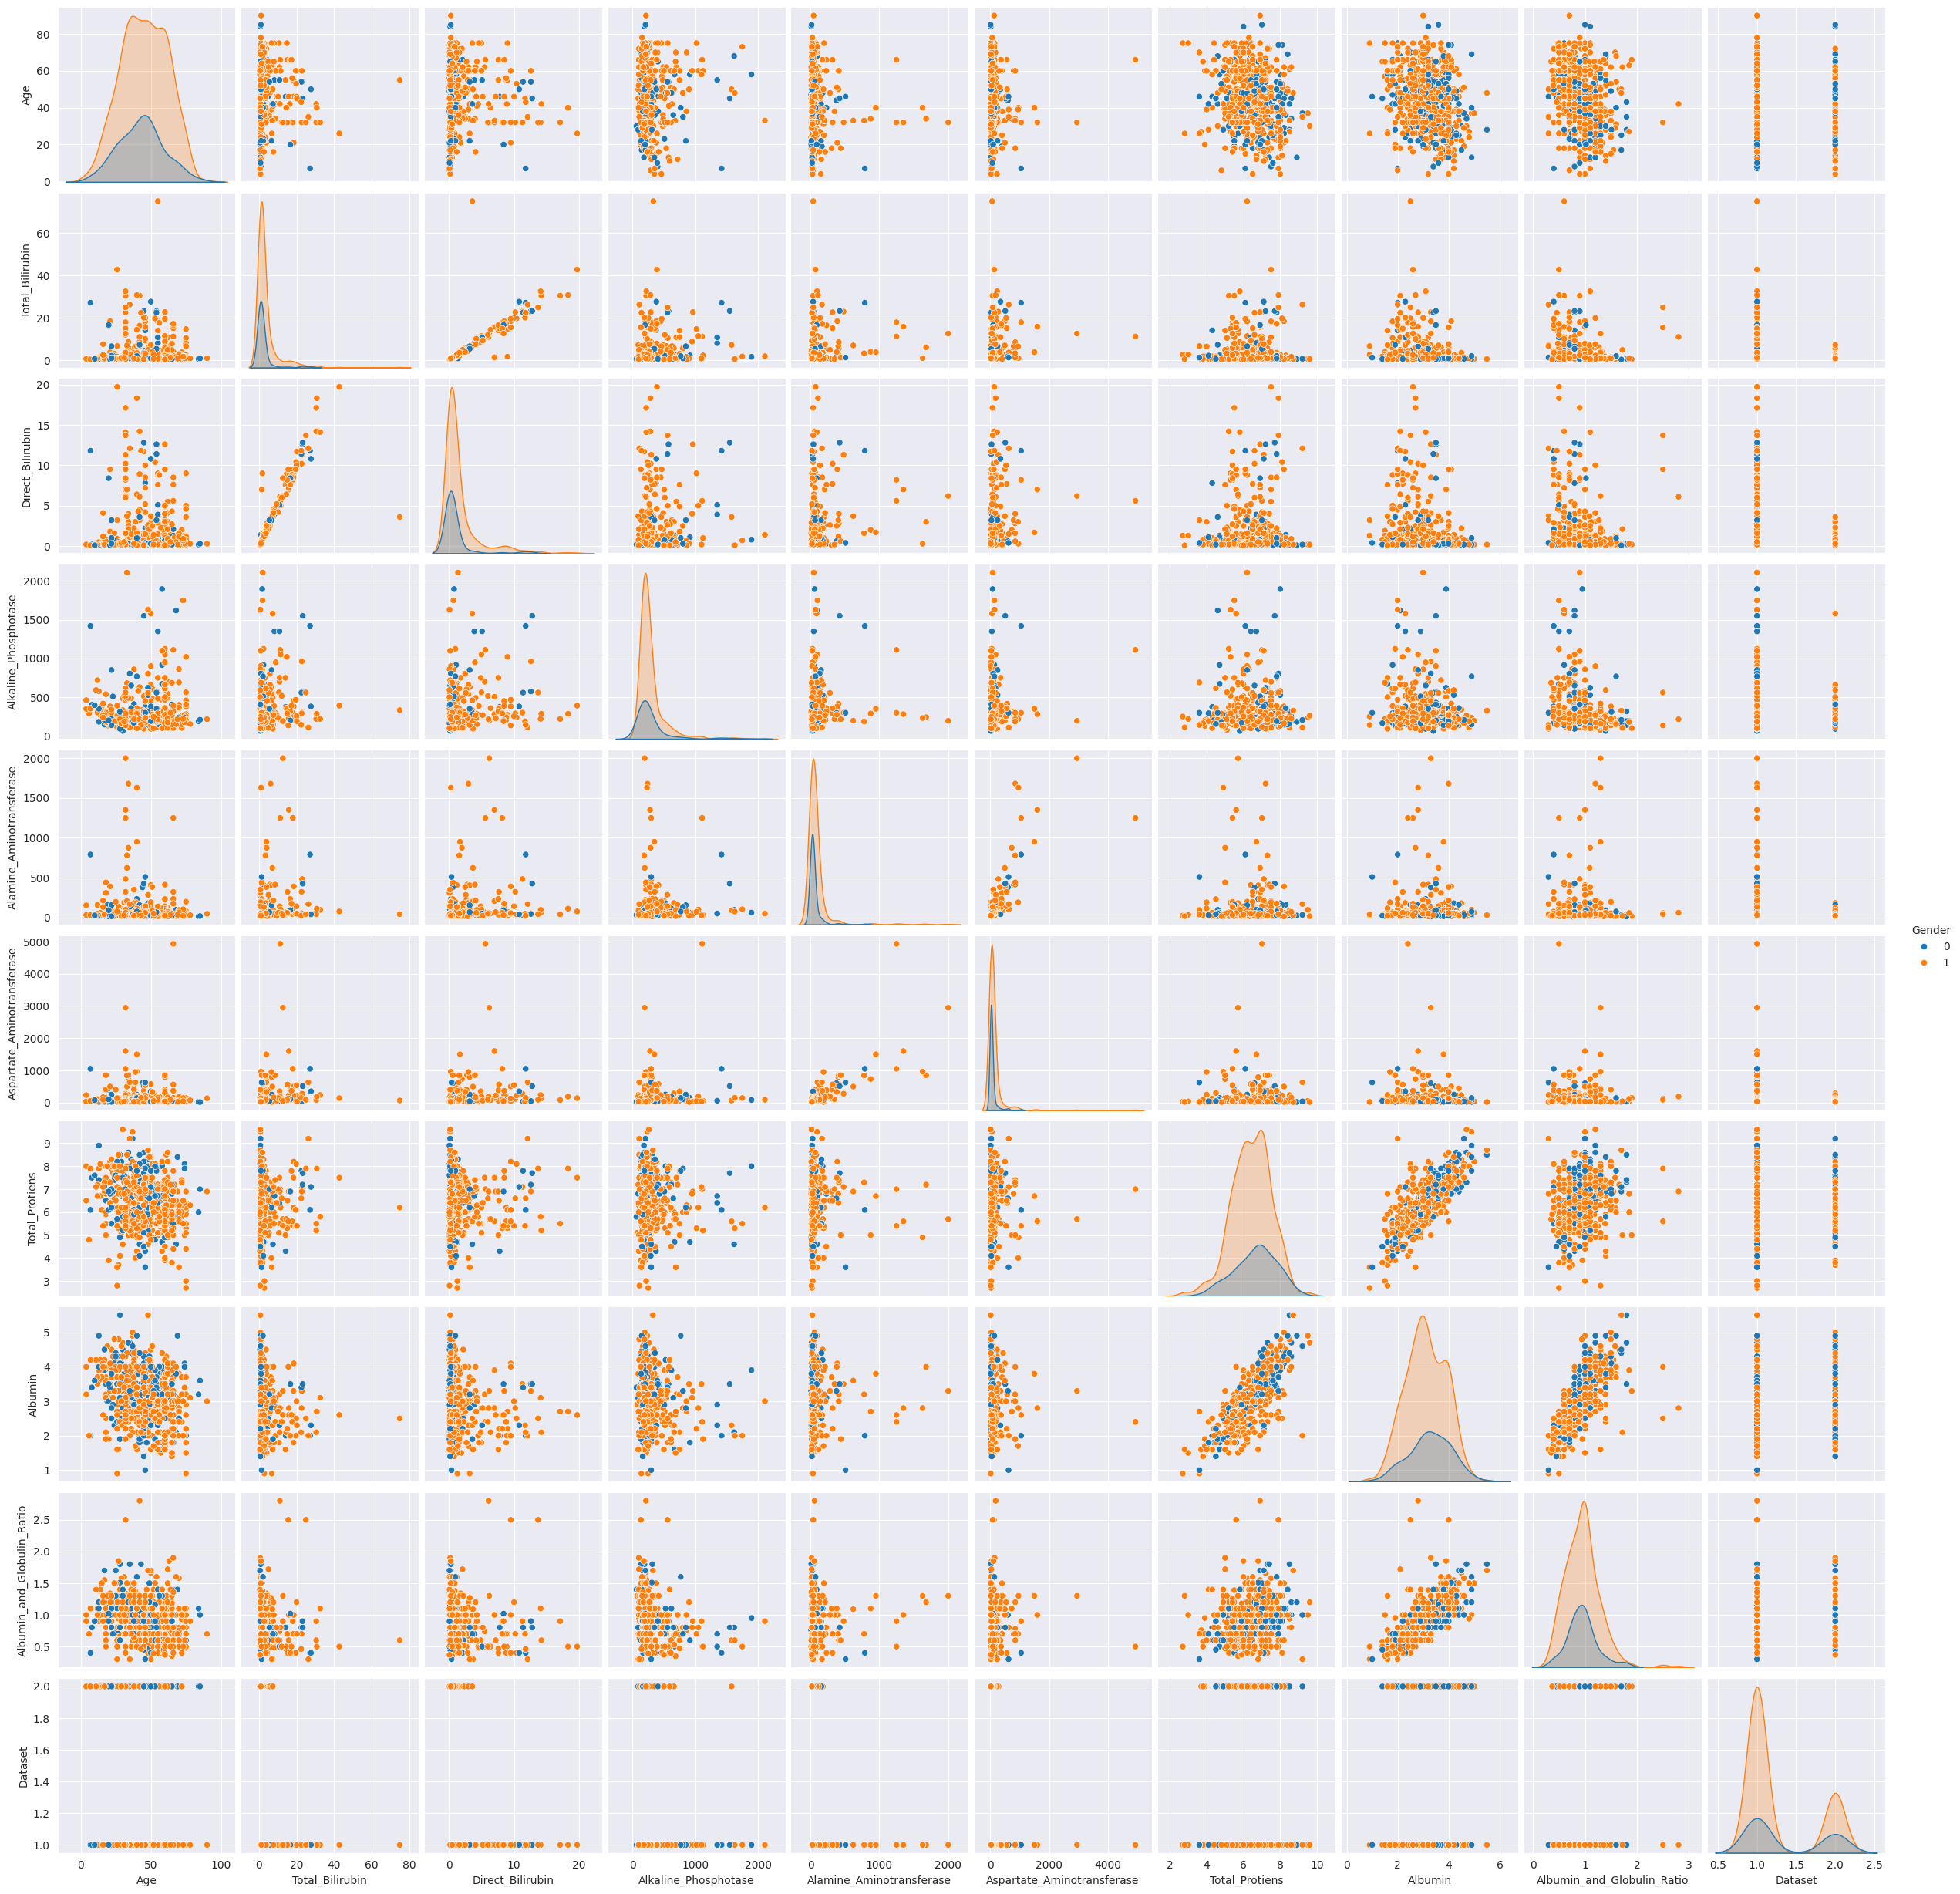

In [57]:
plt.rcParams['figure.figsize']=(10,10)
sns.pairplot(patients,hue='Gender')

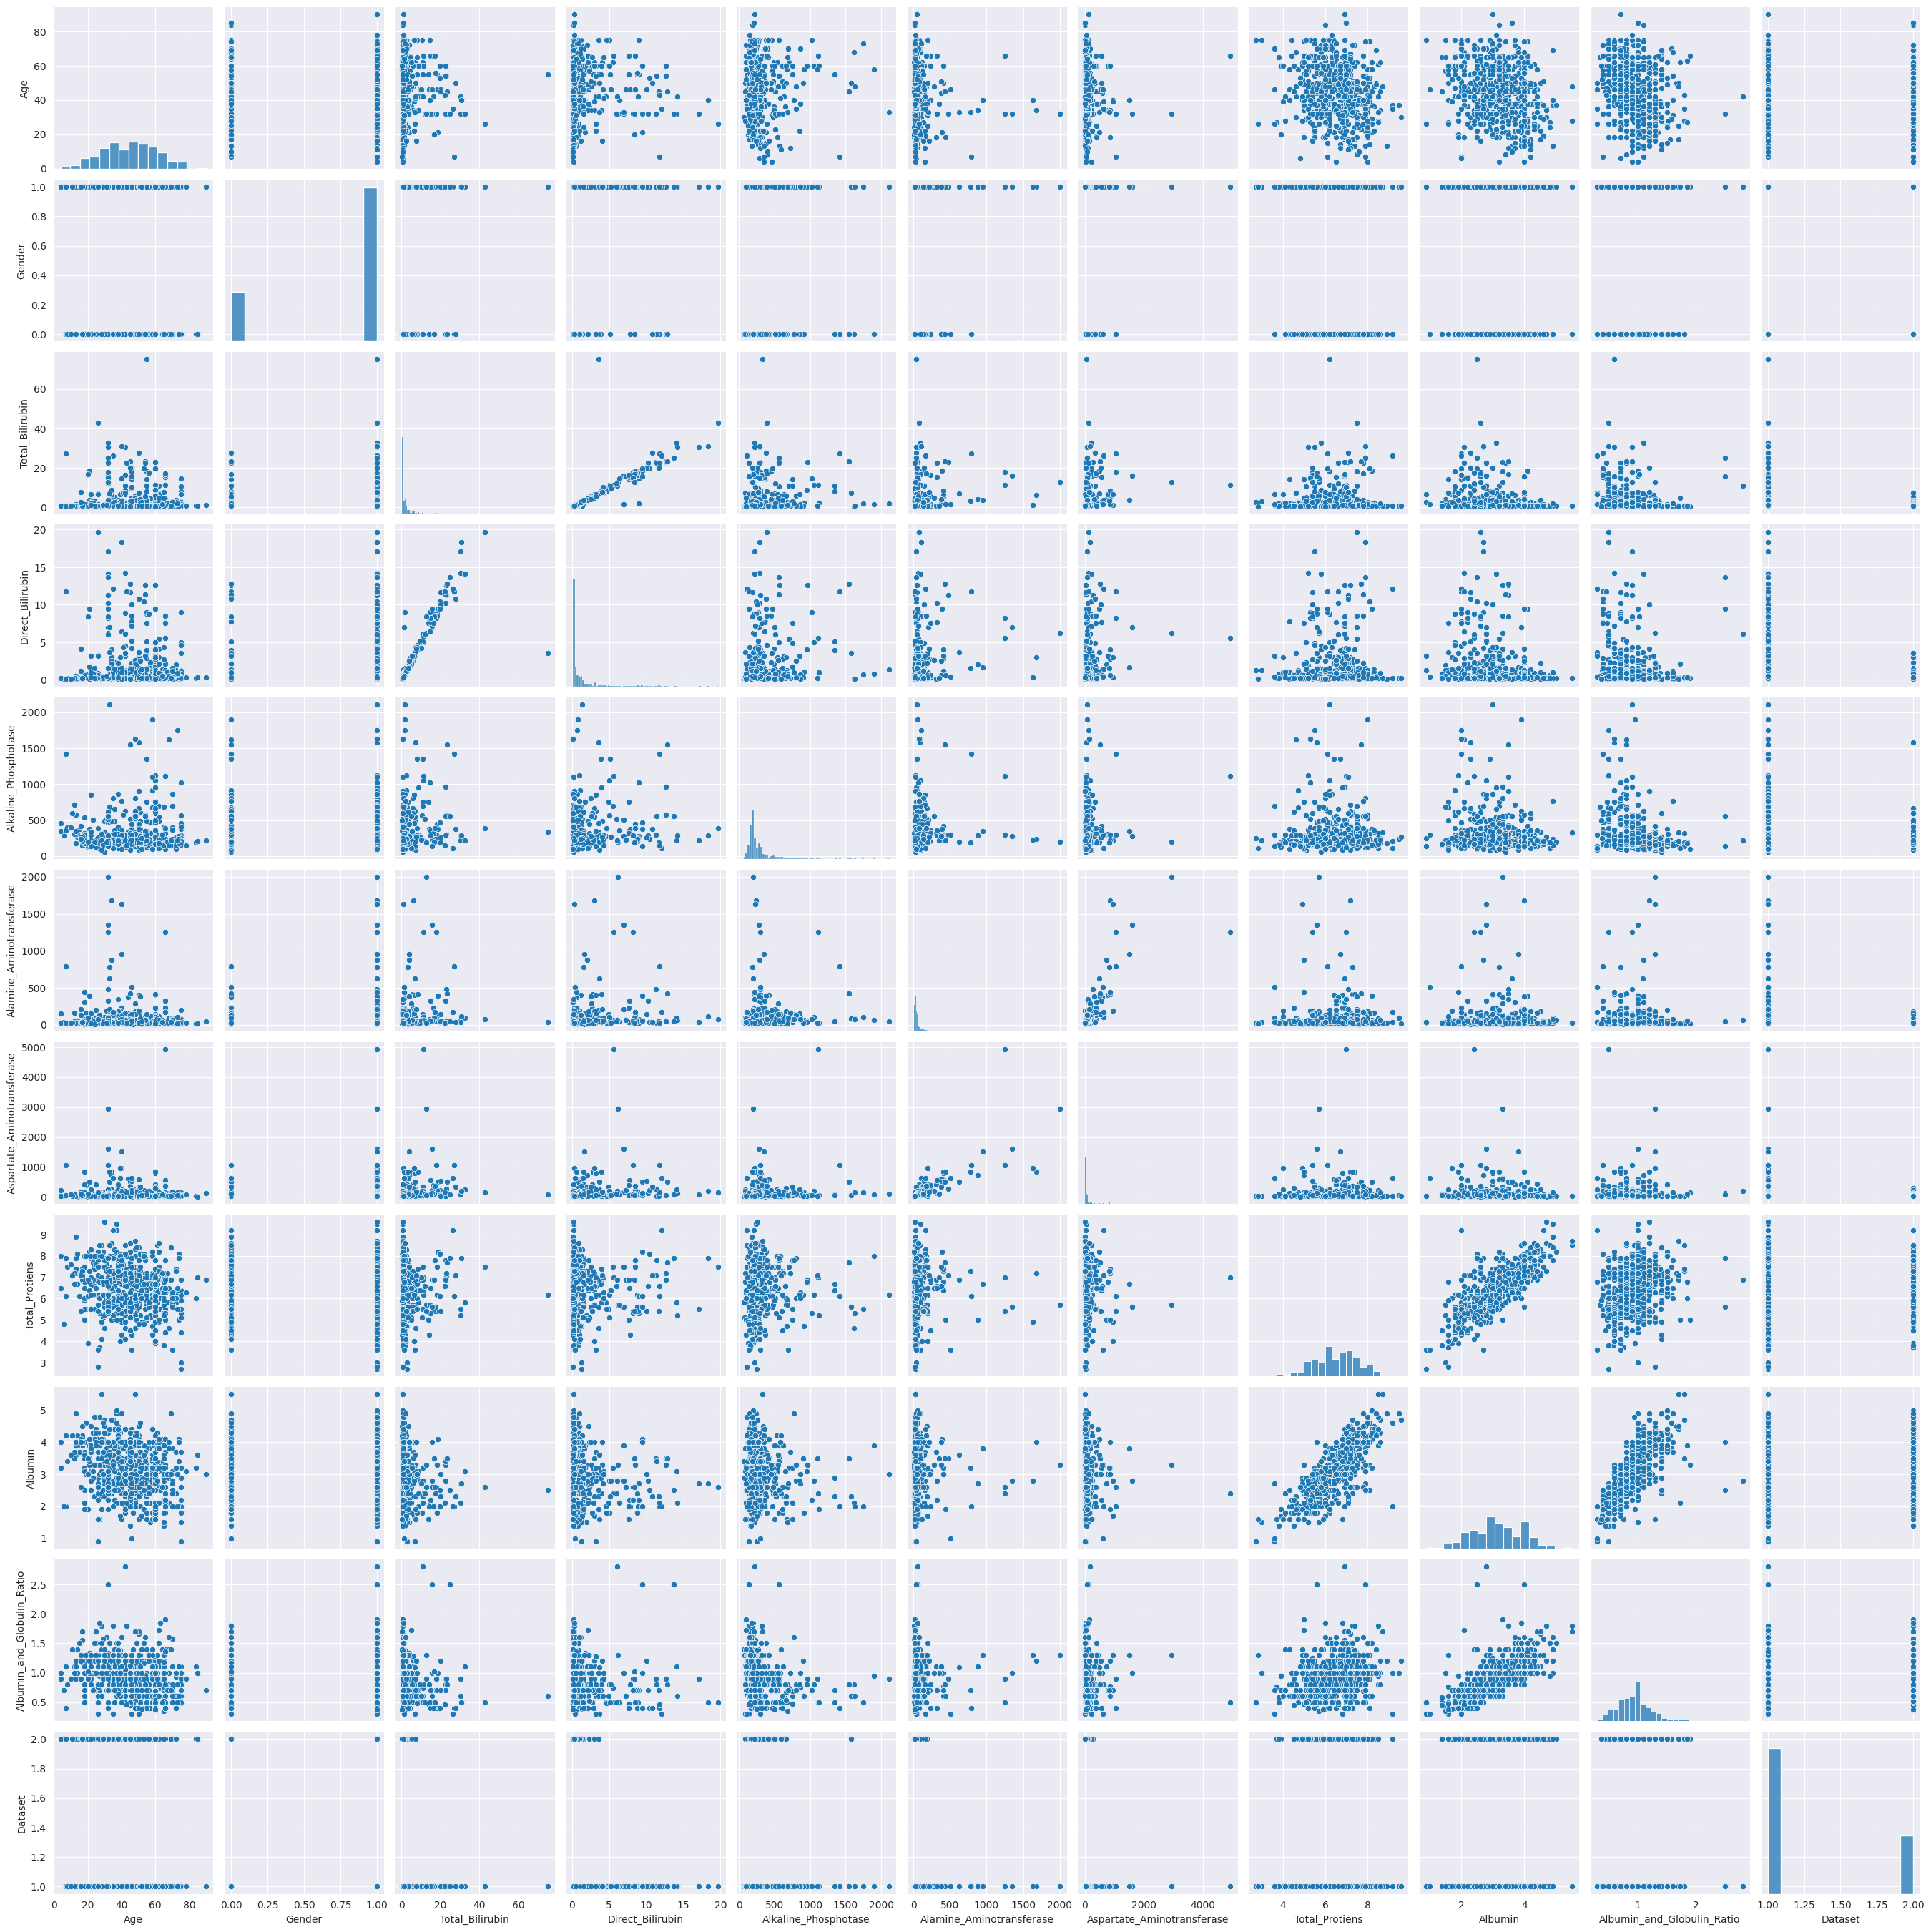

In [58]:
sns.pairplot(patients)

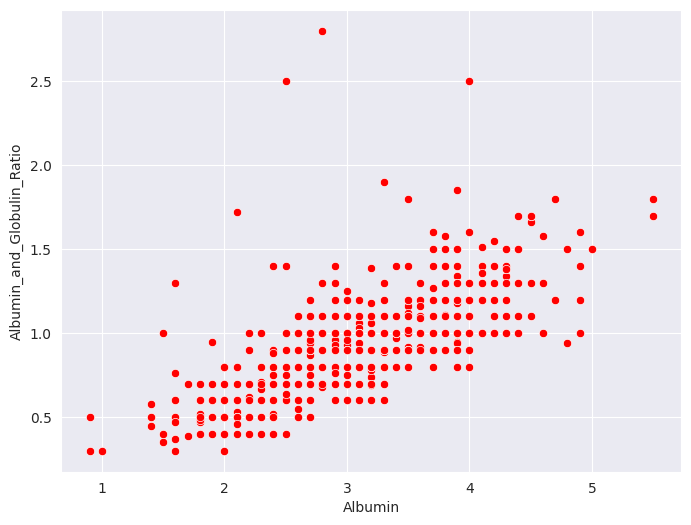

In [59]:
f, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="Albumin", y="Albumin_and_Globulin_Ratio",color='red',data=patients);
plt.show()

<Axes: xlabel='Gender'>

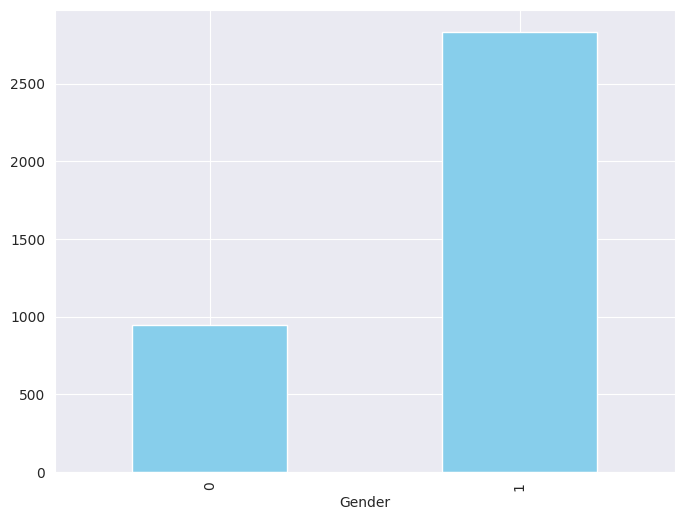

In [60]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').sum()["Total_Protiens"].plot.bar(color='skyblue')

<Axes: xlabel='Gender'>

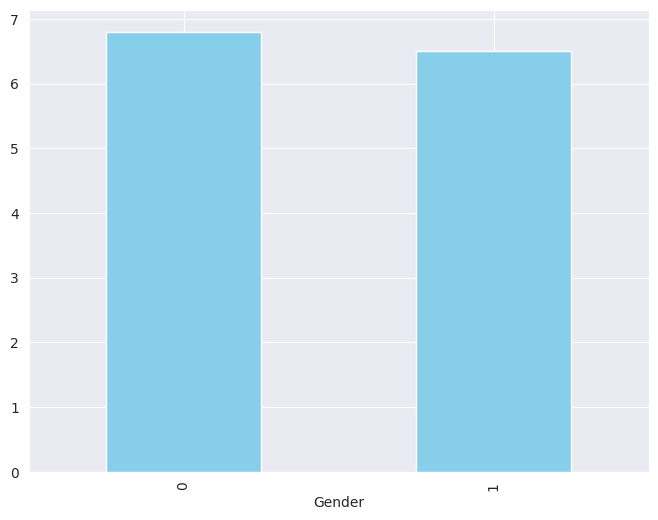

In [61]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').median()["Total_Protiens"].plot.bar(color='skyblue')

<Axes: xlabel='Gender'>

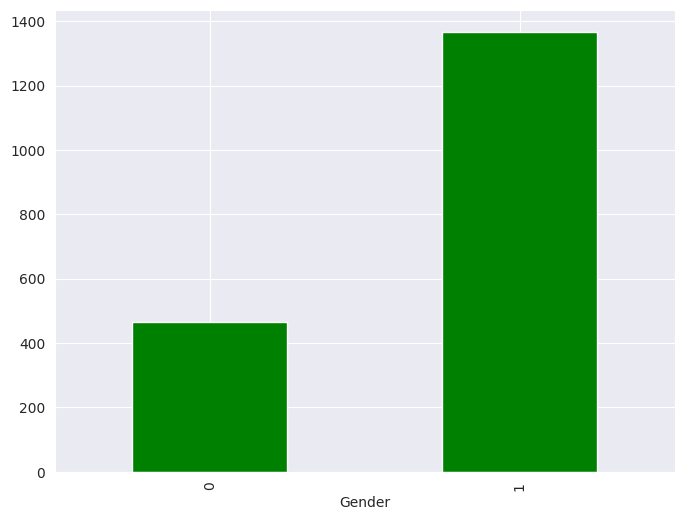

In [62]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').sum()['Albumin'].plot.bar(color='green')

<Axes: xlabel='Gender'>

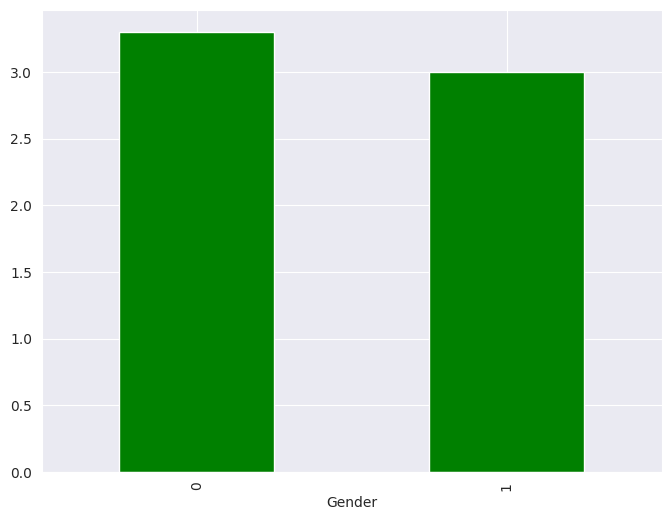

In [63]:
plt.figure(figsize=(8,6))
patients.groupby('Gender').median()['Albumin'].plot.bar(color='green')

In [64]:
corr=patients.corr()

<Axes: >

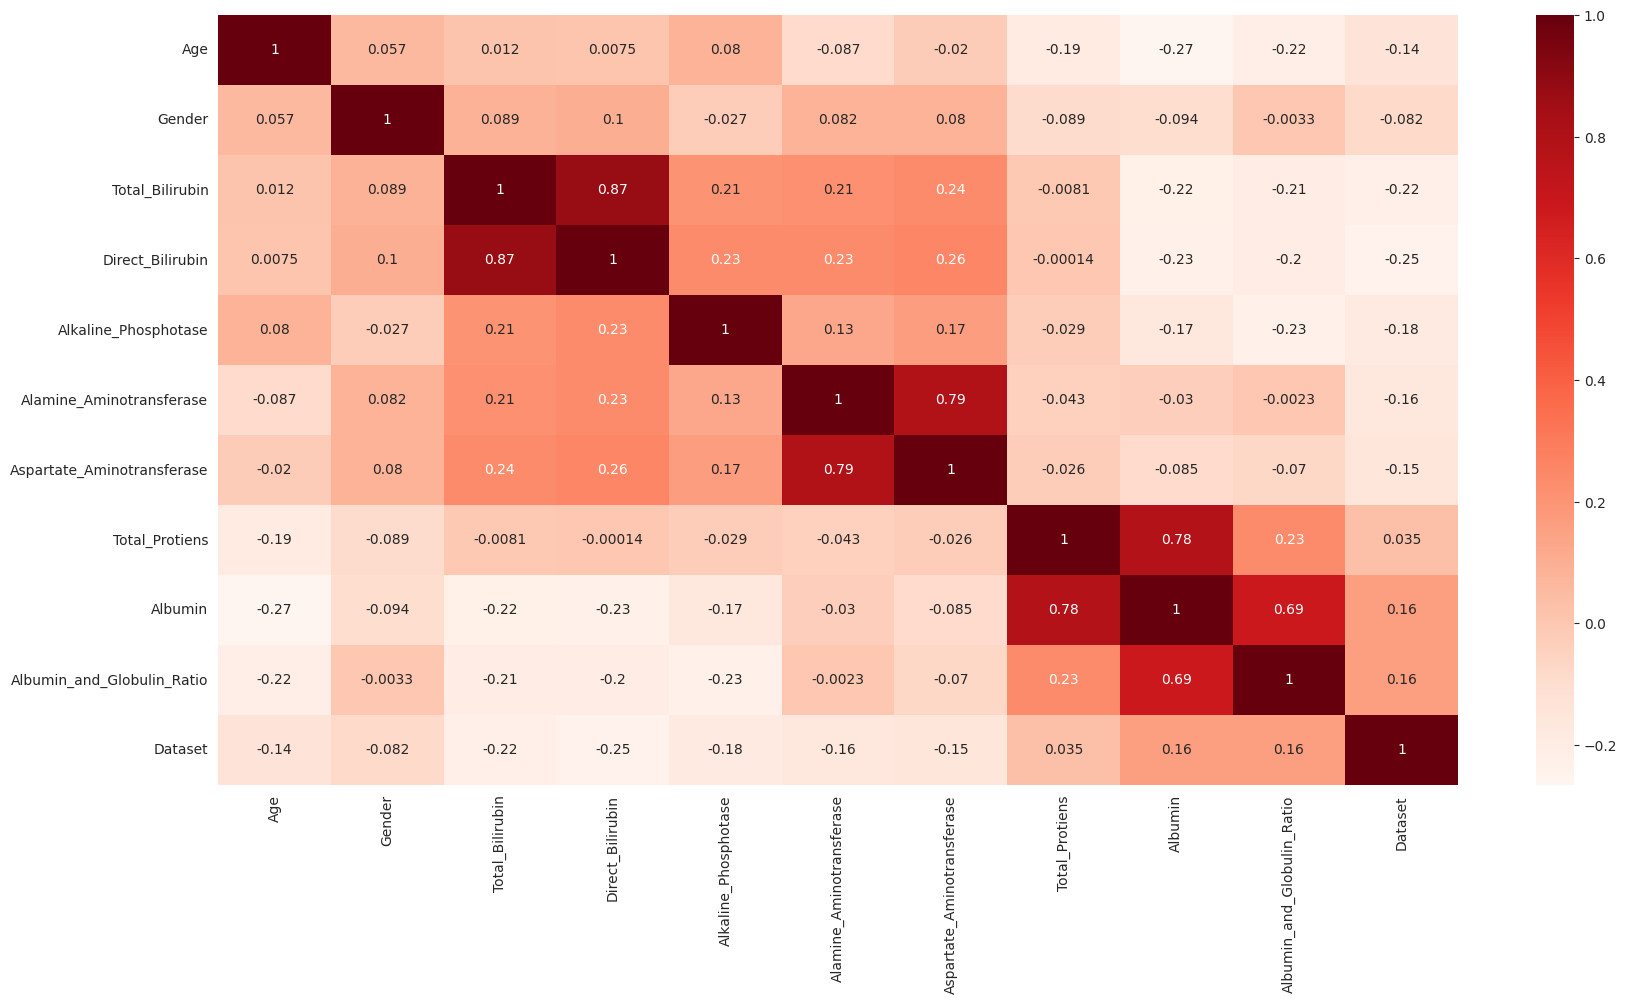

In [65]:
plt.figure(figsize=(20,10))
sns.heatmap(corr,cmap="Reds",annot=True)

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
patients.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [68]:
X=patients[['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio']]
y=patients['Dataset']

In [69]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=123)

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
# adicionado 05Agosto
indice_clase_1 = list(rf_model.classes_).index(1)
y_prob_rf = rf_model.predict_proba(X_test)[:, indice_clase_1]

print('MODELO: Random Forest')
print(classification_report(y_test, y_pred_rf,
                            target_names=["Enfermedad (1)", "Sin enfermedad (2)"]))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print('✅ Modelo entrenado.')

MODELO: Random Forest
                    precision    recall  f1-score   support

    Enfermedad (1)       0.75      0.90      0.82       126
Sin enfermedad (2)       0.48      0.24      0.32        49

          accuracy                           0.71       175
         macro avg       0.62      0.57      0.57       175
      weighted avg       0.68      0.71      0.68       175

ROC-AUC: 0.2630
✅ Modelo entrenado.


In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
# adicionado 05Agosto
indice_clase_1 = list(dt_model.classes_).index(1)
y_prob_dt = dt_model.predict_proba(X_test)[:, indice_clase_1]


print('MODELO: Decision Tree')
print(classification_report(y_test, y_pred_dt,
                            target_names=["Enfermedad (1)", "Sin enfermedad (2)"]))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}')
print('✅ Modelo entrenado.')

MODELO: Decision Tree
                    precision    recall  f1-score   support

    Enfermedad (1)       0.75      0.72      0.73       126
Sin enfermedad (2)       0.34      0.37      0.35        49

          accuracy                           0.62       175
         macro avg       0.54      0.54      0.54       175
      weighted avg       0.63      0.62      0.63       175

ROC-AUC: 0.4552
✅ Modelo entrenado.


In [72]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

# Initialize SVC with probability=True to enable predict_proba
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
# adicionado 05Agosto
indice_clase_1 = list(svm_model.classes_).index(1)
y_prob_svm = svm_model.predict_proba(X_test)[:, indice_clase_1]


print('MODELO: Support Vector Machine')
print(classification_report(y_test, y_pred_svm,
                            target_names=["Enfermedad (1)", "Sin enfermedad (2)"]))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}')
print('✅ Modelo entrenado.')

MODELO: Support Vector Machine
                    precision    recall  f1-score   support

    Enfermedad (1)       0.72      1.00      0.84       126
Sin enfermedad (2)       0.00      0.00      0.00        49

          accuracy                           0.72       175
         macro avg       0.36      0.50      0.42       175
      weighted avg       0.52      0.72      0.60       175

ROC-AUC: 0.2974
✅ Modelo entrenado.


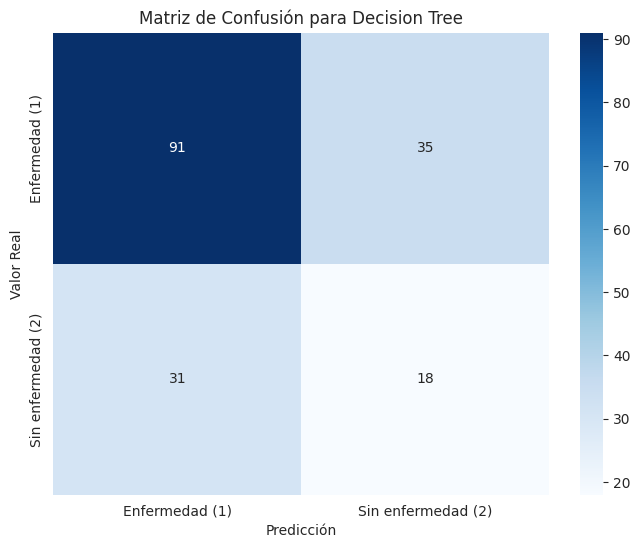

In [73]:
from sklearn.metrics import confusion_matrix
target_names=["Enfermedad (1)", "Sin enfermedad (2)"]
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Decision Tree')
plt.show()

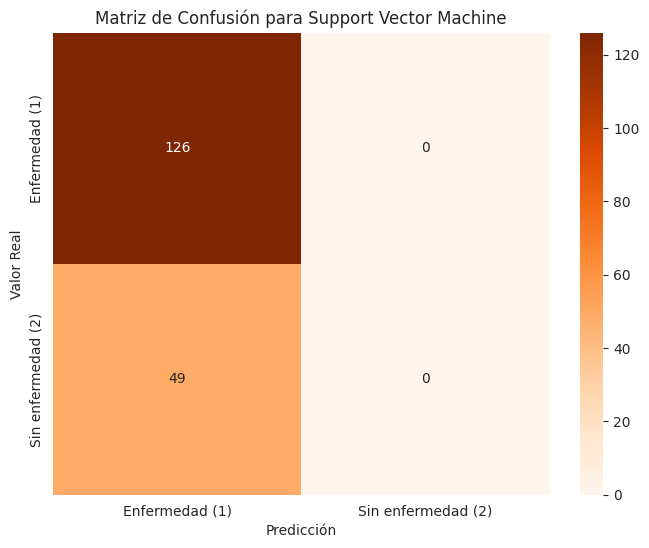

In [74]:
from sklearn.metrics import confusion_matrix
target_names=["Enfermedad (1)", "Sin enfermedad (2)"]
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Support Vector Machine')
plt.show()

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def get_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    # For binary classification, use pos_label=1 (enfermedad) or specify average='binary'
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# Get metrics for each model
metrics_dt = get_metrics(y_test, y_pred_dt)
metrics_rf = get_metrics(y_test, y_pred_rf)
metrics_svm = get_metrics(y_test, y_pred_svm)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Decision Tree': metrics_dt,
    'Random Forest': metrics_rf,
    'Support Vector Machine': metrics_svm
}).T

display(comparison_df.round(4))

,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.6229,0.7459,0.7222,0.7339
Random Forest,0.7143,0.7533,0.8968,0.8188
Support Vector Machine,0.7200,0.7200,1.0000,0.8372


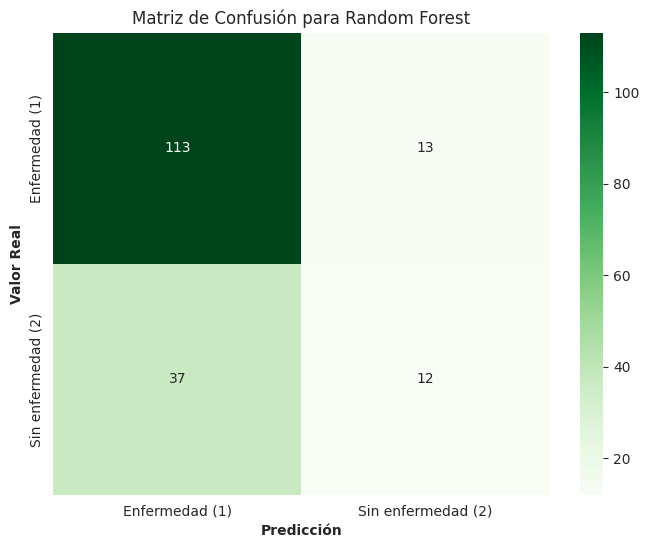

In [76]:
from sklearn.metrics import confusion_matrix
target_names=["Enfermedad (1)", "Sin enfermedad (2)"]
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicción', fontweight='bold')
plt.ylabel('Valor Real', fontweight='bold')
plt.title('Matriz de Confusión para Random Forest')
plt.show()

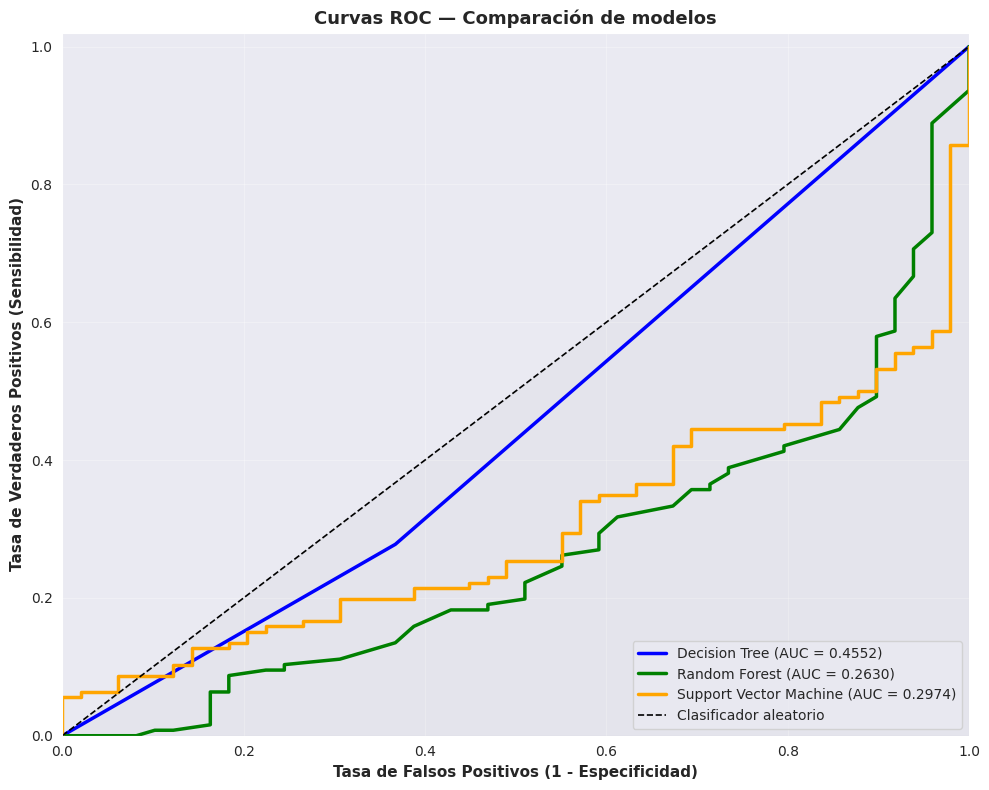

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Probabilities for each model (P(positive class = 1))
# Ensure y_prob_rf and y_prob_svm are defined from previous cells
y_probs = [y_prob_dt, y_prob_rf, y_prob_svm]

models_names = ['Decision Tree', 'Random Forest', 'Support Vector Machine']
models_colors = ['blue', 'green', 'orange']

for y_prob, label, color in zip(probs, models_names, models_colors):
    # 05-Agosto-2026
    y_test_bin = (y_test == 1).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    auc = roc_auc_score(y_test_bin, y_prob)

    # fpr, tpr, _ = roc_curve(y_test, prob, pos_label=1)
    # auc = roc_auc_score(y_test, prob )
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{label} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Clasificador aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')


ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)',fontweight='bold', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)',fontweight='bold', fontsize=11)
ax.set_title('Curvas ROC — Comparación de modelos', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

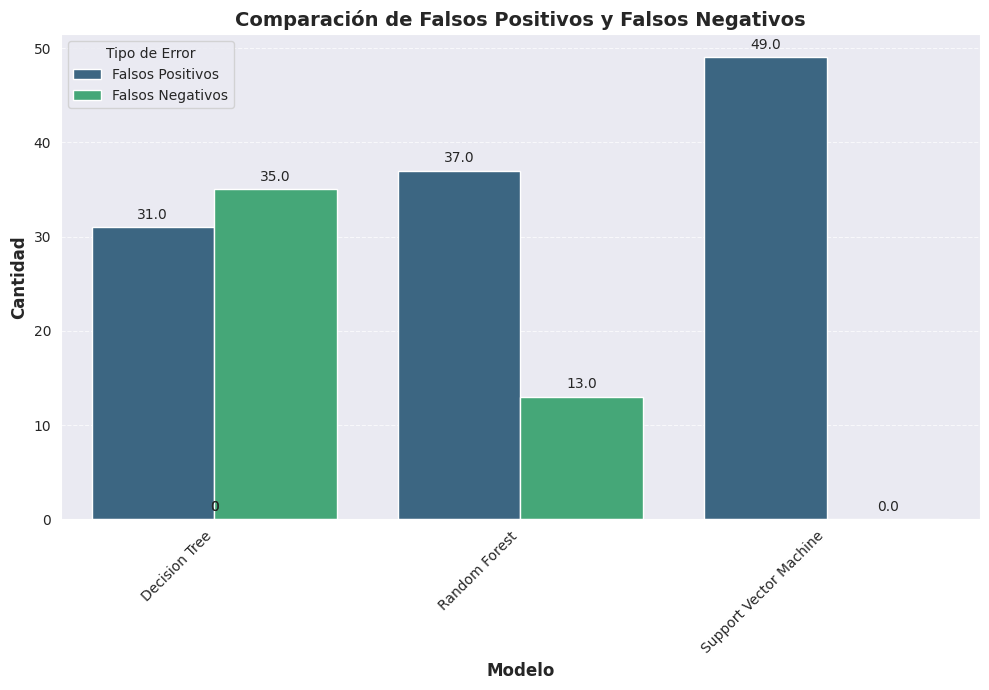

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Extract FP and FN from confusion matrices
# cm_dt: Actual (row), Predicted (col)
# cm[0,1] = False Positives (predicted 1, actual 0)
# cm[1,0] = False Negatives (predicted 0, actual 1)

# NOTE: For binary classification (Dataset values 1 and 2), let's assume '1' is the positive class (Enfermedad)
# and '2' is the negative class (Sin enfermedad). The confusion matrix indices are typically:
# [[TN, FP],
#  [FN, TP]]


fn_dt = cm_dt[0, 1] # Predicted 1 (Enfermedad), Actual 2 (Sin enfermedad)
fp_dt = cm_dt[1, 0] # Predicted 2 (Sin enfermedad), Actual 1 (Enfermedad)


fn_rf = cm_rf[0, 1]
fp_rf = cm_rf[1, 0]

fn_svm = cm_svm[0, 1]
fp_svm = cm_svm[1, 0]

# Create a DataFrame for plotting
metrics_data = {
    'Modelo': ['Decision Tree', 'Random Forest', 'Support Vector Machine'],
    'Falsos Positivos': [fp_dt, fp_rf, fp_svm],
    'Falsos Negativos': [fn_dt, fn_rf, fn_svm]
}
error_df = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
error_df_melted = error_df.melt('Modelo', var_name='Tipo de Error', value_name='Cantidad')

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Modelo', y='Cantidad', hue='Tipo de Error', data=error_df_melted, palette='viridis')
plt.title('Comparación de Falsos Positivos y Falsos Negativos', fontsize=14, fontweight='bold')
plt.xlabel('Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add quantity labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

In [79]:
patients.to_csv('/content/sample_data/patients_preprocessed.csv', index=False)
print('El archivo patients_preprocessed.csv ha sido guardado exitosamente.')

El archivo patients_preprocessed.csv ha sido guardado exitosamente.
